In [6]:
import seaborn as sns
import numpy as np

df = sns.load_dataset("tips")
# Randomly set 5 'tip' and 5 'sex' values to NaN
df.loc[df.sample(5).index, 'tip'] = np.nan
df.loc[df.sample(5).index, 'sex'] = np.nan

df.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [7]:
df.shape

(244, 7)

In [8]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [9]:
df.isnull().sum()

total_bill    0
tip           5
sex           5
smoker        0
day           0
time          0
size          0
dtype: int64

In [10]:
df.describe()

,total_bill,tip,size
count,244.000000,239.00000,244.000000
mean,19.785943,2.98887,2.569672
std,8.902412,1.37521,0.951100
min,3.070000,1.00000,1.000000
25%,13.347500,2.00000,2.000000
50%,17.795000,2.92000,2.000000
75%,24.127500,3.53000,3.000000
max,50.810000,10.00000,6.000000


In [11]:
df.info

<bound method DataFrame.info of      total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67   NaN    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]>

In [14]:
df['tip'].fillna(df['tip'].mean(), inplace=True)
df['sex'].fillna(df['sex'].mode()[0], inplace=True)

C:\Users\Akshay12\AppData\Local\Temp\ipykernel_21212\3252020218.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tip'].fillna(df['tip'].mean(), inplace=True)


Step 3 — Handle Outliers

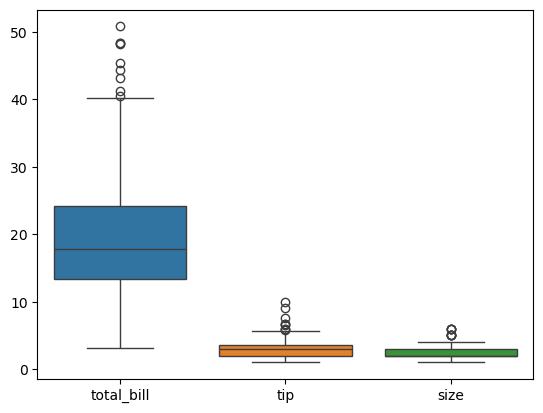

In [15]:
import matplotlib.pyplot as plt
sns.boxplot(data = df[['total_bill','tip','size']])
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd
encoder = LabelEncoder()
for col in ['sex','smoker', 'time']:
    df[col] = encoder.fit_transform(df[col])
df = pd.get_dummies(df, columns=['day'], drop_first=True)

In [19]:
print(df['sex'].unique())

[0 1]


In [22]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler = MinMaxScaler()
df[['total_bill', 'tip', 'size']] = scaler.fit_transform(df[['total_bill', 'tip', 'size']])

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sc = StandardScaler()
mm = MinMaxScaler()

# Apply each scaler separately
standard_scaled = sc.fit_transform(df[['total_bill', 'tip', 'size']])
minmax_scaled = mm.fit_transform(df[['total_bill', 'tip', 'size']])

# Compare stats
print('Original mean:', df[['total_bill', 'tip', 'size']].mean())
print('StandardScaler mean:', standard_scaled.mean(axis=0))
print('MinMaxScaler min:', minmax_scaled.min(axis=0), 'max:', minmax_scaled.max(axis=0))


Original mean: total_bill    0.350145
tip           0.220986
size          0.313934
dtype: float64
StandardScaler mean: [-3.08268893e-17 -8.73618118e-17 -3.20326643e-16]
MinMaxScaler min: [0. 0. 0.] max: [1. 1. 1.]


In [27]:
df_fe = df.copy()
# 1. Tip percentage
df_fe['tip_percent'] = (df_fe['tip'] / df_fe['total_bill']) * 100
# 2. Bill per person
df_fe['bill_per_person'] = (df_fe['total_bill'] / df_fe['size'])
#Create a new feature generous_tip:
#If tip_percent > 20, label as “Generous”
#Else “Average”
df_fe['generous_tip'] = df_fe['tip'].apply(lambda x: 'Generous' if x > 20 else 'Average')
# 4. Weekend indicator
#1 if day is Saturday or Sunday, else 0
#df_fe['weekend_indicator'] = df_fe['day'].apply(lambda x:1 if x in ['Sat', 'Sun'] else 0)
df_fe.head()

,total_bill,tip,sex,smoker,time,size,day_Fri,day_Sat,day_Sun,tip_percent,bill_per_person,generous_tip
0,0.291579,0.001111,0,0,0,0.2,False,False,True,0.381066,1.457897,Average
1,0.152283,0.073333,1,0,0,0.4,False,False,True,48.155892,0.380708,Average
2,0.375786,0.277778,1,0,0,0.4,False,False,True,73.919237,0.939464,Average
3,0.431713,0.256667,1,0,0,0.2,False,False,True,59.453016,2.158567,Average
4,0.450775,0.290000,0,0,0,0.6,False,False,True,64.333643,0.751292,Average


Step 7 — Feature Selection

Compute the correlation matrix for numerical features.

Visualize correlations using a heatmap.

Identify highly correlated pairs and remove redundant features.

Use:

SelectKBest (based on ANOVA F-test)

Feature Importance (from RandomForestRegressor or Classifier)

Compare which features appear most influential for predicting tip or tip_percent.

Step 8 — Data Transformation

Check if total_bill, tip, or tip_percent are skewed.

Apply transformations to reduce skewness:

Log Transformation

Square Root Transformation

Yeo-Johnson / Box-Cox (using PowerTransformer)

Plot histograms before and after transformation.

Discuss which transformation works best.

Step 9 — Train-Test Split (Optional for Feature Testing)

Choose tip_percent as target variable.

Split dataset into train (80%) and test (20%).

Train a simple Linear Regression model to predict tip_percent.

Evaluate the model using R² and RMSE.

Discuss which features contributed most to predictions.

Step 10 — Practical Analysis & Visualization

Find which day of the week has the highest average tip.

Compare average tip percentage by smoker vs non-smoker.

Plot relationship between size of table and total bill.

Find which gender gives higher tips on average.

Visualize tip_percent distribution across days using boxplots